In [1]:
include("./trajopt/utils.jl")
include("./trajopt/dynamics.jl")
include("./funlopt/funl_dynamics.jl")
include("./funlopt/funl_utils.jl")
include("./funlopt/funl_constraint.jl")
include("./trajopt/scaling.jl")

compute_scaling (generic function with 1 method)

In [2]:
# load nominal trajectory
using JLD2, FileIO
filename = "./data/traj_result" 
@load filename my_dict
xnom = my_dict["x"]
unom = my_dict["u"]
tnom = my_dict["t"];
Nnom = size(xnom,2) - 1
dtnom = zeros(Nnom)
for i in 1:Nnom
    dtnom[i] = tnom[i+1]-tnom[i]
end

In [3]:
filename = "./data/funnel_result" 
@load filename funl_dict
Qnom = funl_dict["Q2"]
Ynom = funl_dict["Y2"]
N1 = size(Qnom,3) - 1
@assert(Nnom == N1)

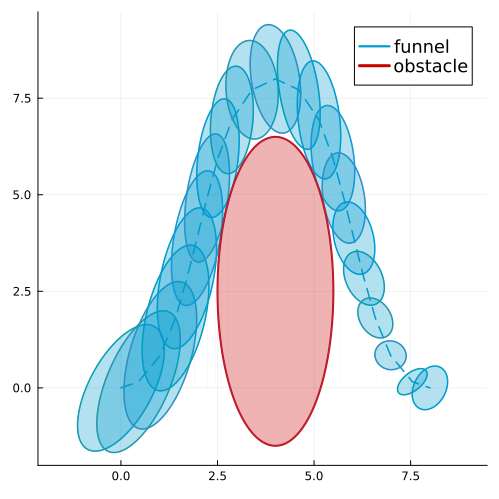

In [4]:
function get_H_obs(rx,ry)
    return diagm([1/rx,1/ry])
end
c_list = []
H_list = []
push!(c_list, [4.0, 2.5])
push!(H_list, get_H_obs(1.5, 4.0))

p2 = Plots.plot(; size=(500,500))
plot!(xnom[1,:],xnom[2,:],aspect_ratio=:equal,c=:deepskyblue3,linestyle=:dash,linewidth=1.5,label=nothing)
for idx in 1:Nnom+1
    label = nothing
    if idx == 1
        label = "funnel"
    end
    plot_ellipse(p2,Qnom[:,:,idx],xnom[:,idx],"deepskyblue3",linewidth=1.5,label=label,fill=true)
end
for (idx,(ce, H)) in enumerate(zip(c_list, H_list))
    label = nothing
    if idx == 1
        label = "obstacle"
    end
    plot_ellipse(p2,inv(H)*inv(H),ce,"red3",label=label)
end
display(p2)

# Approximate the unicycle model as polynomaial dynamics

In [118]:
# Setting.
using SumOfSquares
using MosekTools
using Clarabel
using DynamicPolynomials

ix = 3
iu = 2
iw = 2
dynamics = Unicycle()
c1 = dynamics.c1
c2 = dynamics.c2

deg_V = 4
deg_L = 4

@polyvar w[1:2]
@polyvar eta[1:3]

g0 = 1 - eta' * inv(Qnom[:,:,1]) * eta
monos_V = monomials(eta, 1:deg_V);

In [119]:
# Closed-loop system.
# function eval_closed_loop_system(idx,eta,w)
#     K = Ynom[:,:,idx] * inv(Qnom[:,:,idx])
#     u = unom[:,idx] + K * eta
#     sin_theta_bar = sin(xnom[3,idx])
#     cos_theta_bar = cos(xnom[3,idx])
#     f1 = u[1] * (cos_theta_bar + (-sin_theta_bar) * (eta[3])
#                             + (-cos_theta_bar/2) * (eta[3])^2
#                             + (sin_theta_bar/6) * (eta[3])^3) - unom[1,idx] * cos_theta_bar
#     f2 = u[1] * (sin_theta_bar + (cos_theta_bar) * (eta[3])
#                             + (-sin_theta_bar/2) * (eta[3])^2
#                             + (-cos_theta_bar/6) * (eta[3])^3) - unom[1,idx] * sin_theta_bar
#     f3 = u[2] - unom[2,idx]
#     f = [f1;f2;f3]
#     return f
# end

function eval_closed_loop_system_with_disturbance(idx,eta,w)
    K = Ynom[:,:,idx] * inv(Qnom[:,:,idx])
    u = unom[:,idx] + K * eta
    sin_theta_bar = sin(xnom[3,idx])
    cos_theta_bar = cos(xnom[3,idx])
    f1 = u[1] * (cos_theta_bar + (-sin_theta_bar) * (eta[3] + c1 * w[1])
                            # + (-cos_theta_bar/2) * (eta[3] + c1 * w[1])^2
                            # + (sin_theta_bar/6) * (eta[3] + c1 * w[1])^3
                            ) - unom[1,idx] * cos_theta_bar
    f2 = u[1] * (sin_theta_bar + (cos_theta_bar) * (eta[3] + c1 * w[1])
                            # + (-sin_theta_bar/2) * (eta[3] + c1 * w[1])^2
                            # + (-cos_theta_bar/6) * (eta[3] + c1 * w[1])^3
                            ) - unom[1,idx] * sin_theta_bar
    f3 = u[2] + c2 * w[2] - unom[2,idx]
    f = [f1;f2;f3]
    return f
end

eval_closed_loop_system_with_disturbance (generic function with 1 method)

In [125]:
N = 1
function build_model(;freeze_V::Bool, L_prev=nothing, LE_prev=nothing, V_prev=nothing, rho_prev=nothing)
    # Setting.
    solver = optimizer_with_attributes(Mosek.Optimizer, MOI.Silent() => true)
    # solver = optimizer_with_attributes(Clarabel.Optimizer, MOI.Silent() => true)
    model = SOSModel(solver);

    if freeze_V
        # Lyapunov function is frozen.
        println("Freezing Lyapunov.")
        V = V_prev
        rho = rho_prev

        # Mutlipliers.
        L = @variable(model, [1:N+1], Poly(monomials(vcat(eta,w), 0:deg_L)))
        LE = @variable(model, [1:N+1], Poly(monomials(eta, 0:deg_L)))
        # L = L_prev
        # LE = LE_prev
        for i in 1:N+1
            @constraint(model, L[i] in SOSCone())
            @constraint(model, LE[i] in SOSCone())
        end
    else
        # Lyapunov function.
        V = @variable(model, [1:N+1], Poly(monos_V))
        rho = @variable(model, [1:N+1])
        for i in 1:N+1
            @constraint(model, V[i] in SOSCone())
            @constraint(model, rho[i] >= 0)
        end

        # Multipliers are frozen.
        println("Freezing multipliers.")
        L = L_prev
        LE = LE_prev
    end

    # PSD matrix for the outer ellipsoid of the funnel.
    S_scale = diag([1e1 1e1 1e2])
    Scvx = []
    for i in 1:(N+1)
        push!(Scvx, @variable(model, [1:ix, 1:ix], PSD))
    end
    # very_small = 1e-9
    # for i in 1:N+1
    #     @constraint(model, S[i] >= very_small .* Matrix(1.0I,ix,ix), PSDCone())
    # end

    # Multiplier for the initial condition.
    @variable(model, L0, Poly(monomials(eta, 0:deg_L)))
    @constraint(model, L0 in SOSCone())

    # Multiplier for the bounde disturbance.
    Lw = @variable(model, [1:N+1], Poly(monomials(vcat(eta,w), 0:deg_L)))
    for i in 1:N+1
        @constraint(model, Lw[i] in SOSCone())
    end

    for idx in 1:N+1
        # # Lyapunov condition.
        if (idx <= N)
            rhodot = (rho[idx+1] - rho[idx]) / (tnom[idx+1] - tnom[idx])
            Vdot_t = (V[idx+1] - V[idx]) / (tnom[idx+1] - tnom[idx])
        else
            rhodot = (rho[idx] - rho[idx-1]) / (tnom[idx] - tnom[idx-1])
            Vdot_t = (V[idx] - V[idx-1]) / (tnom[idx] - tnom[idx-1])
        end
        # Vdot = dot(differentiate(V[idx], eta), eval_closed_loop_system(idx,eta,nothing)) + Vdot_t
        # @constraint(model, rhodot - Vdot - L[idx] * (V[idx] - rho[idx]) >= 0)

        Vdot = dot(differentiate(V[idx], eta), eval_closed_loop_system_with_disturbance(idx,eta,w)) + Vdot_t
        @constraint(model, rhodot - Vdot - L[idx] * (V[idx] - rho[idx]) - Lw[idx] * (1 - w' * w) in SOSCone())

        # Outer bound on the funnel.
        S = S_scale * Scvx[idx] * S_scale
        @constraint(model, 1 - eta' * S * eta - LE[idx] * (rho[idx] - V[idx]) in SOSCone())
    end

    # # Initial boundary condition.
    @constraint(model, rho[1] - V[1] - L0 * g0 in SOSCone())

    # Cost function.
    @variable(model, log_det_S[1:N+1])
    for idx in 1:N+1
        S = S_scale * Scvx[idx] * S_scale
        @constraint(model, [log_det_S[idx]; 1; vec(S[idx])] in MOI.LogDetConeSquare(ix))
    end
    @objective(model, Min, -sum(log_det_S))

    # @variable(model, log_det_S_end)
    # @constraint(model, [log_det_S_end; 1; vec(S[end])] in MOI.LogDetConeSquare(ix))
    # @objective(model, Min, -sum(log_det_S_end))


    # @objective(model, Max, sum(tr.(S)))
    S = []
    for i in 1:(N+1)
        push!(S, S_scale * value(Scvx[idx]) * S_scale)
    end
    return model, (V, rho, L, LE, Lw, L0, S)
end

build_model (generic function with 1 method)

In [126]:
max_iter = 1
Ssos = zeros(ix,ix,N+1)
Qsos = zeros(ix,ix,N+1)

# Initial guess.
L_prev = 1 * ones(N+1)
LE_prev = 100 * ones(N+1)

# V_prev = [eta' * inv(Qnom[:,:,idx]) * eta for idx in 1:N+1]
# rho_prev = ones(N+1)

for iter in 1:max_iter
    # Update V and rho.
    model, (V, rho, _, _, Lw,L0,S) = build_model(freeze_V = false, 
                                                L_prev = L_prev, 
                                                LE_prev = LE_prev)

    # Solve.
    optimize!(model)
    @show termination_status(model)

    V_prev = value.(V)
    rho_prev = value.(rho)
    println("V: ",V_prev)
    println("rho: ",rho_prev)
    println("Lw: ",value.(Lw))
    println("L0: ",value.(L0))
    println("S: ",value.(S))

    println("Objective value: ", objective_value(model))
    println("--")
    # Update L and LE.

    # model, (_, _, L, LE, Lw, L0, S) = build_model(freeze_V = true, 
    #                                             V_prev = V_prev, 
    #                                             rho_prev = rho_prev)

    # # Solve.
    # optimize!(model)
    # @show termination_status(model)

    # L_prev = value.(L)
    # LE_prev = value.(LE)
    # println(L_prev)
    # println(LE_prev)

    # println("Objective value: ", objective_value(model))
    # println("--")

    for i in 1:(N+1)
        Ssos[:,:,i] .= value.(S[i])
        Qsos[:,:,i] .= inv(value.(S[i]))
    end

end

Freezing multipliers.


DimensionMismatch: DimensionMismatch: matrix A has dimensions (1,1), matrix B has dimensions (3,3)

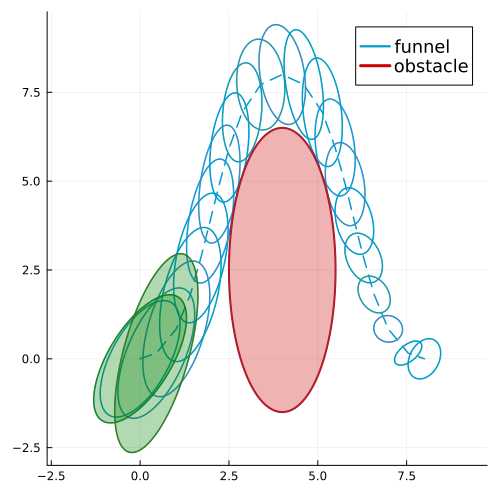

In [122]:
p2 = Plots.plot(; size=(500,500))
plot!(xnom[1,:],xnom[2,:],aspect_ratio=:equal,c=:deepskyblue3,linestyle=:dash,linewidth=1.5,label=nothing)
for idx in 1:Nnom+1
    label = nothing
    if idx == 1
        label = "funnel"
    end
    plot_ellipse(p2,Qnom[:,:,idx],xnom[:,idx],"deepskyblue3",linewidth=1.5,label=label,fill=false)
end
for idx in 1:N+1
    plot_ellipse(p2,Qsos[:,:,idx],xnom[:,idx],"green",linewidth=1.5,fill=true)
end
for (idx,(ce, H)) in enumerate(zip(c_list, H_list))
    label = nothing
    if idx == 1
        label = "obstacle"
    end
    plot_ellipse(p2,inv(H)*inv(H),ce,"red3",label=label)
end
display(p2)

In [10]:
include("./funlopt/funl_utils.jl")
u_fit = [LinearInterpolation(tnom, unom[idx,:],extrapolation_bc=Flat()) for idx in 1:iu]
Q_fit = [[LinearInterpolation(tnom, Qnom[i,j,:], extrapolation_bc=Flat()) for j in 1:ix] for i in 1:ix ]
Y_fit = [[LinearInterpolation(tnom, Ynom[i,j,:], extrapolation_bc=Flat()) for j in 1:ix] for i in 1:iu ]
;

In [ ]:
num_sample = 500
xs_list = []
for i in 1:num_sample
    z = randn(ix)
    z = z / norm(z)
    push!(xs_list,xnom[:,1] + sqrt(Qnom[:,:,1]) * z)
end

In [ ]:
xsam_fwd,tsam,xsam,usam,xnomprop = [],[],[],[],[]
i = 0
for xs in xs_list
    # println(i)
    i += 1
    xf_,ts_,xsam_,usam_,xnom_ = propagate_from_funnel_entry_uncertain_dynamics(xs,
        dynamics,
        xnom,unom,tnom,
        Qnom,Ynom)
    push!(xsam_fwd,xf_)
    push!(tsam,ts_)
    push!(xsam,xsam_)
    push!(usam,usam_)
    push!(xnomprop,xnom_)
end

In [ ]:
p2 = Plots.plot(; size=(500,500))
plot!(xnom[1,:],xnom[2,:],aspect_ratio=:equal,c=:deepskyblue3,linestyle=:dash,linewidth=1.5,label=nothing)
for idx in 1:Nnom+1
    label = nothing
    if idx == 1
        label = "funnel"
    end
    plot_ellipse(p2,Qnom[:,:,idx],xnom[:,idx],"deepskyblue3",linewidth=1.5,label=label,fill=false)
end
for idx in 1:N+1
    plot_ellipse(p2,Qsos[:,:,idx],xnom[:,idx],"green",linewidth=1.5,fill=true)
end
for (idx,(ce, H)) in enumerate(zip(c_list, H_list))
    label = nothing
    if idx == 1
        label = "obstacle"
    end
    plot_ellipse(p2,inv(H)*inv(H),ce,"red3",label=label)
end
for x_ in xsam
    plot!(x_[1,:],x_[2,:],color="purple",label=nothing)
end
display(p2)

In [ ]:
# Lyapunov function
V_fit = LinearInterpolation(tnom, V_prev, extrapolation_bc=Flat())
rho_fit = LinearInterpolation(tnom, rho_prev, extrapolation_bc=Flat())

Lypsam = []
rhosam = []
idx = 1
for idx = 1:length(tsam)
    tsam_ = tsam[idx]
    xsam_ = xsam[idx]
    xprop_ = xnomprop[idx]
    Lyp = []
    # rho_ = []
    for iode in 1:length(tsam_)
        t_ = tsam_[iode]
        x_ = xsam_[:,iode]
        xnom_ = xprop_[:,iode]
        eta_ = x_ - xnom_
        V_ = V_fit(t_)
        subs = Dict(eta[1] => eta_[1], eta[2] => eta_[2], eta[3] => eta_[3])  
        push!(Lyp,V_(subs...) / rho_fit(t_))
    end
    push!(Lypsam,Lyp)
    # push!(rhosam,rho_)
end


In [ ]:
p3 = Plots.plot(; size=(500,300))
for idx = 1:length(tsam)
    plot!(tsam[idx],Lypsam[idx],c=:purple,label="")
end
plot!(tsam[1],tsam[1]*0 .+ 1.0,c=:red,linestyle=:dash,label="")
display(p3)